The following code was used to extract and analyse the first SQUID loop designs.

## CST simulation flux line analysis ##

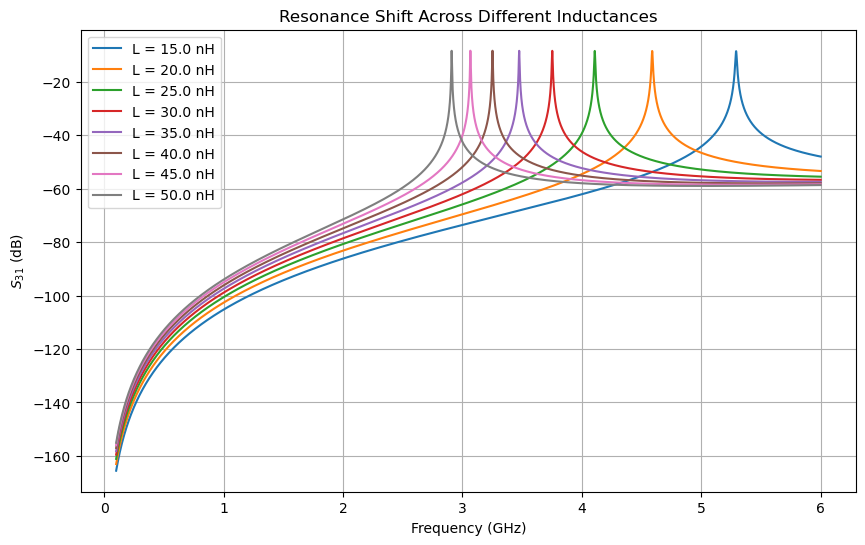

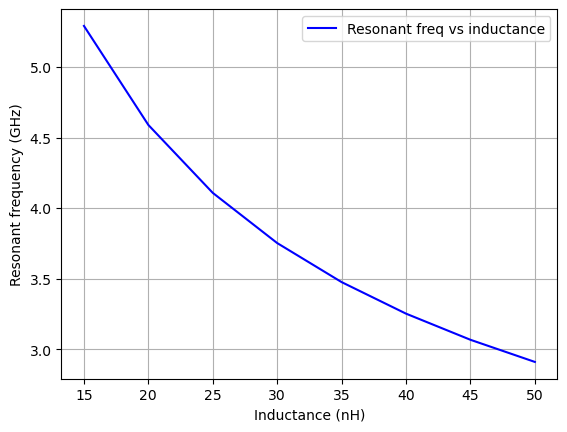

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Initialize variables to parse the stacked file
current_inductance = None
data_by_inductance = {}

# 2. Open and split the file by inductance values
with open('Corrected_Flux_Resonance.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        # When we find a new sweep header, extract the inductance value
        if line.startswith('#Parameters'):
            match = re.search(r'inductance=([\d\.]+)', line)
            if match:
                current_inductance = float(match.group(1))
                data_by_inductance[current_inductance] = []
        elif line.startswith('#'):
            continue  # Skip other comment rows
        else:
            # Append numerical rows to the active inductance sweep
            if current_inductance is not None:
                parts = line.split()
                if len(parts) == 2:
                    data_by_inductance[current_inductance].append([float(parts[0]), float(parts[1])])

# 3. Process each sweep to find its resonance peak
inductances = []
res_freq_design0 = []
res_mag_design0 = []

plt.figure(figsize=(10, 6))
for L in sorted(data_by_inductance.keys()):
    # Convert lists to a clean 2D NumPy array
    arr = np.array(data_by_inductance[L])
    freq = arr[:, 0]  # Frequency (GHz)
    mag = arr[:, 1]   # Magnitude (dB)
    
    # Locate the highest peak (maximum voltage transmission)
    peak_idx = np.argmax(mag)
    f_peak = freq[peak_idx]
    mag_peak = mag[peak_idx]
    
    # Save values for the final analysis
    inductances.append(L)
    res_freq_design0.append(f_peak)
    res_mag_design0.append(mag_peak)
    
    # Plot the individual curve to see the resonance shifts
    plt.plot(freq, mag, label=f'L = {L} nH')

plt.xlabel('Frequency (GHz)')
plt.ylabel(r"$S_{31}$ (dB)")
plt.title('Resonance Shift Across Different Inductances')
plt.legend()
plt.grid(True)
plt.show()

# Convert tracking lists to NumPy arrays for calculations
inductances = np.array(inductances)
res_freq_design0 = np.array(res_freq_design0)

plt.plot(inductances, res_freq_design0, 'b', label='Resonant freq vs inductance')
plt.xlabel('Inductance (nH)')
plt.ylabel('Resonant frequency (GHz)')
plt.legend()
plt.grid(True)
plt.show()

#Also importing voltage in of port 1 mode 1:
design0_voltage_data = np.loadtxt('Design0_Voltage_In.txt', comments='#')
design0_voltage_in_db = np.array(design0_voltage_data[:, 1])
design0_voltage_frequency = np.array(design0_voltage_data[:, 0])

<function matplotlib.pyplot.show(close=None, block=None)>

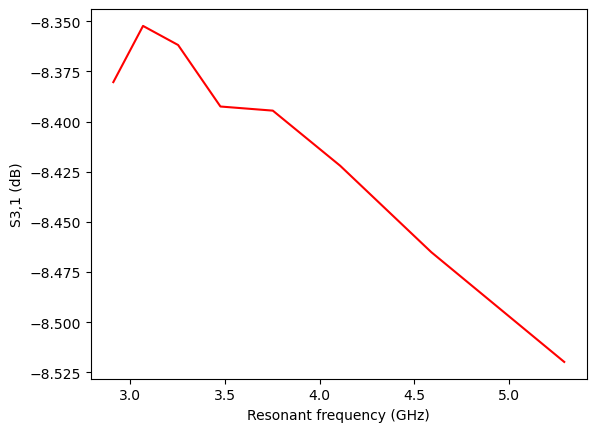

In [2]:
#max S parameter vs frequency plot
plt.plot(res_freq_design0,res_mag_design0, 'r')
plt.xlabel('Resonant frequency (GHz)')
plt.ylabel('S3,1 (dB)')
plt.show


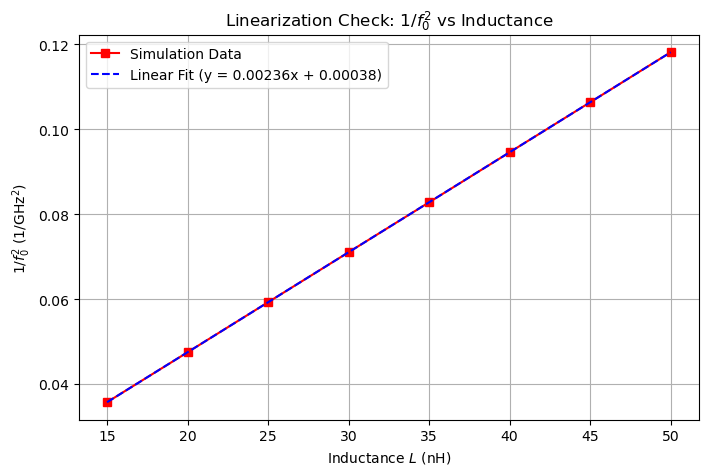

Qubit capacitance is: 0.00005966 nF
Or Qubit capacitance: 59.66 fF


In [3]:
# 4. Physics Check: Plot 1 / f_0^2 vs Inductance to extract capacitance
plt.figure(figsize=(8, 5))
y_vals = 1.0 / (res_freq_design0 ** 2)
plt.plot(inductances, y_vals, 's-', color='red', label='Simulation Data')

# Fit a line (y = mx + c)
slope, intercept = np.polyfit(inductances, y_vals, 1)
plt.plot(inductances, slope * inductances + intercept, '--', color='blue', 
         label=f'Linear Fit (y = {slope:.5f}x + {intercept:.5f})')

plt.xlabel('Inductance $L$ (nH)')
plt.ylabel('$1 / f_0^2$ ($1/\mathrm{GHz}^2$)')
plt.title('Linearization Check: $1/f_0^2$ vs Inductance')
plt.legend()
plt.grid(True)
plt.show()

#Capacitance calculation:
Qubit_capacitance = slope/(4*np.pi**2)
print(f'Qubit capacitance is: {Qubit_capacitance:.8f} nF')
print(f'Or Qubit capacitance: {Qubit_capacitance*1e6:.2f} fF')

## CST simulation drive line analysis ##

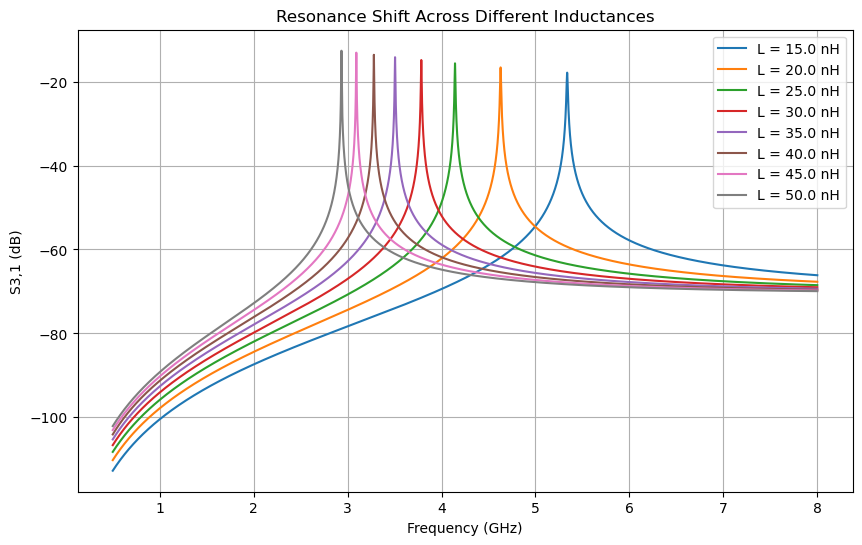

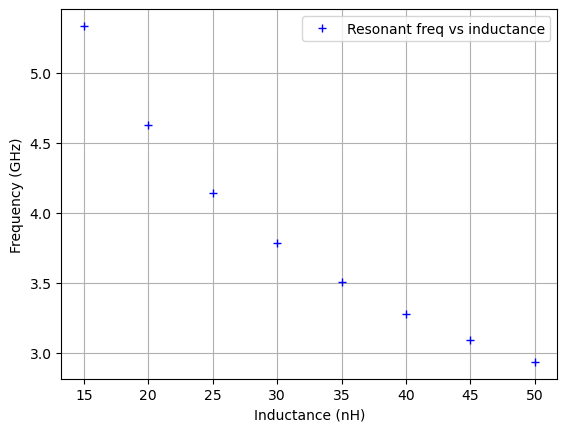

In [4]:
# 1. Initialize variables to parse the stacked file
current_inductance = None
data_by_inductance = {}

# 2. Open and split the file by inductance values
with open('Design0_drive_drive.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        # When we find a new sweep header, extract the inductance value
        if line.startswith('#Parameters'):
            match = re.search(r'inductance=([\d\.]+)', line)
            if match:
                current_inductance = float(match.group(1))
                data_by_inductance[current_inductance] = []
        elif line.startswith('#'):
            continue  # Skip other comment rows
        else:
            # Append numerical rows to the active inductance sweep
            if current_inductance is not None:
                parts = line.split()
                if len(parts) == 2:
                    data_by_inductance[current_inductance].append([float(parts[0]), float(parts[1])])

# 3. Process each sweep to find its resonance peak
inductances = []
res_freq_design0_drive = []
res_mag_design0_drive = []

plt.figure(figsize=(10, 6))
for L in sorted(data_by_inductance.keys()):
    # Convert lists to a clean 2D NumPy array
    arr = np.array(data_by_inductance[L])
    freq = arr[:, 0]  # Frequency (GHz)
    mag = arr[:, 1]   # Magnitude (dB)
    
    # Locate the highest peak (maximum voltage transmission)
    peak_idx = np.argmax(mag)
    f_peak = freq[peak_idx]
    mag_peak = mag[peak_idx]
    
    # Save values for the final analysis
    inductances.append(L)
    res_freq_design0_drive.append(f_peak)
    res_mag_design0_drive.append(mag_peak)
    
    # Plot the individual curve to see the resonance shifts
    plt.plot(freq, mag, label=f'L = {L} nH')

plt.xlabel('Frequency (GHz)')
plt.ylabel('S3,1 (dB)')
plt.title('Resonance Shift Across Different Inductances')
plt.legend()
plt.grid(True)
plt.show()

# Convert tracking lists to NumPy arrays for calculations
inductances = np.array(inductances)
res_freq_design0_drive = np.array(res_freq_design0_drive)

plt.plot(inductances, res_freq_design0_drive, 'b+', label='Resonant freq vs inductance')
plt.xlabel('Inductance (nH)')
plt.ylabel('Frequency (GHz)')
plt.legend()
plt.grid(True)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

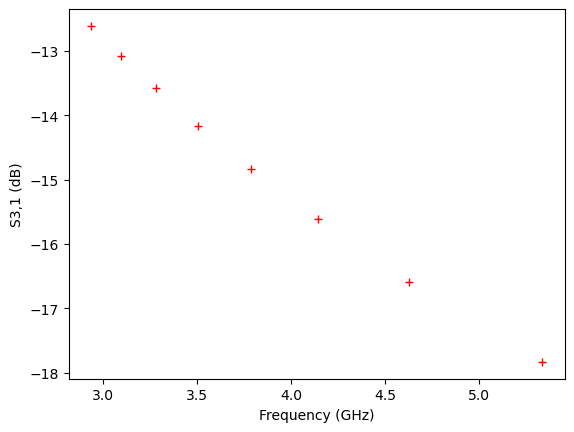

In [5]:
#max S parameter vs frequency plot
plt.plot(res_freq_design0_drive,res_mag_design0_drive,'r+')
plt.xlabel('Frequency (GHz)')
plt.ylabel('S3,1 (dB)')
plt.show


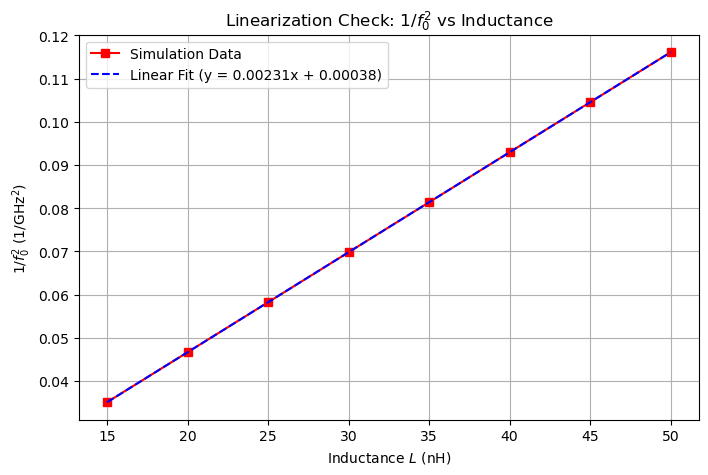

Qubit capacitance is: 0.00005863 nF
Or Qubit capacitance: 58.63 fF


In [6]:
# 4. Physics Check: Plot 1 / f_0^2 vs Inductance to extract capacitance
plt.figure(figsize=(8, 5))
y_vals = 1.0 / (res_freq_design0_drive ** 2)
plt.plot(inductances, y_vals, 's-', color='red', label='Simulation Data')

# Fit a line (y = mx + c)
slope, intercept = np.polyfit(inductances, y_vals, 1) #slope = m , intercept = c
plt.plot(inductances, slope * inductances + intercept, '--', color='blue', 
         label=f'Linear Fit (y = {slope:.5f}x + {intercept:.5f})')

plt.xlabel('Inductance $L$ (nH)')
plt.ylabel('$1 / f_0^2$ ($1/\mathrm{GHz}^2$)')
plt.title('Linearization Check: $1/f_0^2$ vs Inductance')
plt.legend()
plt.grid(True)
plt.show()

#Inductance calculation:
Qubit_inductance = slope/(4*np.pi**2)
print(f'Qubit capacitance is: {Qubit_inductance:.8f} nF')
print(f'Or Qubit capacitance: {Qubit_inductance*1e6:.2f} fF')

# Design 1 Drive Drive #

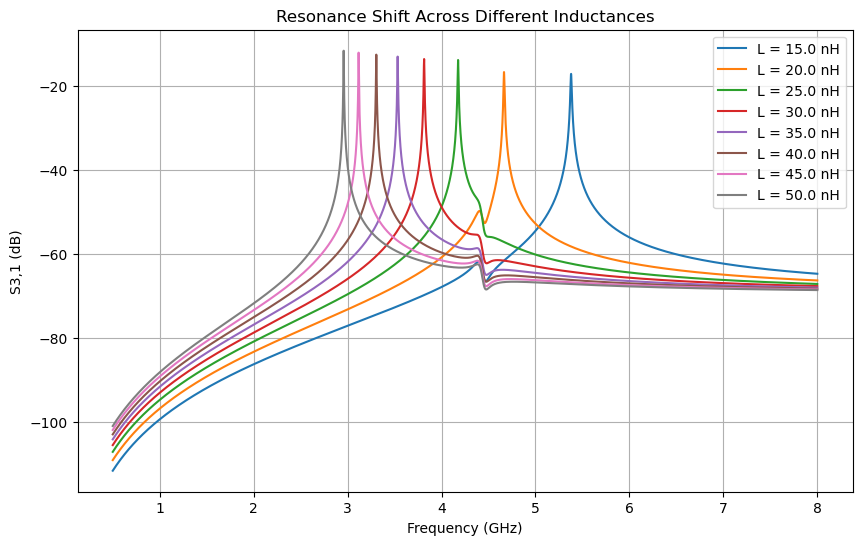

In [7]:
# 1. Initialize variables to parse the stacked file
current_inductance = None
data_by_inductance = {}

# 2. Open and split the file by inductance values
with open('design1_drive_drive.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        # When we find a new sweep header, extract the inductance value
        if line.startswith('#Parameters'):
            match = re.search(r'inductance=([\d\.]+)', line)
            if match:
                current_inductance = float(match.group(1))
                data_by_inductance[current_inductance] = []
        elif line.startswith('#'):
            continue  # Skip other comment rows
        else:
            # Append numerical rows to the active inductance sweep
            if current_inductance is not None:
                parts = line.split()
                if len(parts) == 2:
                    data_by_inductance[current_inductance].append([float(parts[0]), float(parts[1])])

# 3. Process each sweep to find its resonance peak
inductances = []
res_freq_design1_drive = []
res_mag_design1_drive = []

plt.figure(figsize=(10, 6))
for L in sorted(data_by_inductance.keys()):
    # Convert lists to a clean 2D NumPy array
    arr = np.array(data_by_inductance[L])
    freq = arr[:, 0]  # Frequency (GHz)
    mag = arr[:, 1]   # Magnitude (dB)
    
    # Locate the highest peak (maximum voltage transmission)
    peak_idx = np.argmax(mag)
    f_peak = freq[peak_idx]
    mag_peak = mag[peak_idx]
    
    # Save values for the final analysis
    inductances.append(L)
    res_freq_design1_drive.append(f_peak)
    res_mag_design1_drive.append(mag_peak)
    
    # Plot the individual curve to see the resonance shifts
    plt.plot(freq, mag, label=f'L = {L} nH')

plt.xlabel('Frequency (GHz)')
plt.ylabel('S3,1 (dB)')
plt.title('Resonance Shift Across Different Inductances')
plt.legend()
plt.grid(True)
plt.show()

# Convert tracking lists to NumPy arrays for calculations
inductances = np.array(inductances)
res_freq_design1_drive = np.array(res_freq_design1_drive)

#plt.plot(inductances, res_freq_design1_drive, 'b+', label='Resonant freq vs inductance')
#plt.xlabel('Inductance (nH)')
#plt.ylabel('Frequency (GHz)')
#plt.legend()
#plt.grid(True)
#plt.show()

## CST Design 1 flux drive ##

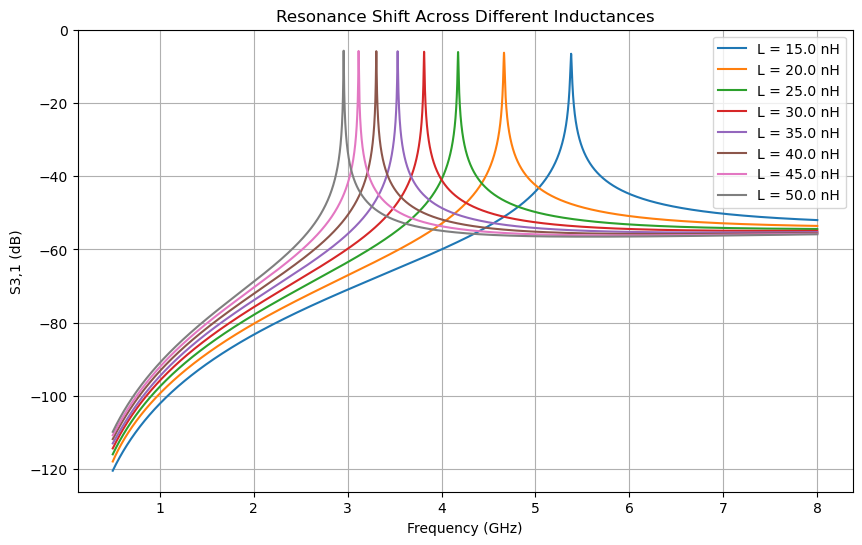

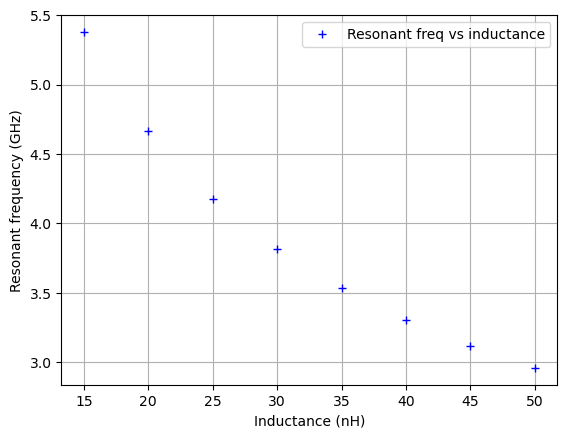

In [8]:
# 1. Initialize variables to parse the stacked file
current_inductance = None
data_by_inductance = {}

# 2. Open and split the file by inductance values
with open('Design1_flux_drive.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        # When we find a new sweep header, extract the inductance value
        if line.startswith('#Parameters'):
            match = re.search(r'inductance=([\d\.]+)', line)
            if match:
                current_inductance = float(match.group(1))
                data_by_inductance[current_inductance] = []
        elif line.startswith('#'):
            continue  # Skip other comment rows
        else:
            # Append numerical rows to the active inductance sweep
            if current_inductance is not None:
                parts = line.split()
                if len(parts) == 2:
                    data_by_inductance[current_inductance].append([float(parts[0]), float(parts[1])])

# 3. Process each sweep to find its resonance peak
inductances = []
res_freq_design1 = []
res_mag_design1 = []

plt.figure(figsize=(10, 6))
for L in sorted(data_by_inductance.keys()):
    # Convert lists to a clean 2D NumPy array
    arr = np.array(data_by_inductance[L])
    freq = arr[:, 0]  # Frequency (GHz)
    mag = arr[:, 1]   # Magnitude (dB)
    
    # Locate the highest peak (maximum voltage transmission)
    peak_idx = np.argmax(mag)
    f_peak = freq[peak_idx]
    mag_peak = mag[peak_idx]
    
    # Save values for the final analysis
    inductances.append(L)
    res_freq_design1.append(f_peak)
    res_mag_design1.append(mag_peak)
    
    # Plot the individual curve to see the resonance shifts
    plt.plot(freq, mag, label=f'L = {L} nH')

plt.xlabel('Frequency (GHz)')
plt.ylabel('S3,1 (dB)')
plt.title('Resonance Shift Across Different Inductances')
plt.legend()
plt.grid(True)
plt.show()

# Convert tracking lists to NumPy arrays for calculations
inductances = np.array(inductances)
res_freq_design1 = np.array(res_freq_design1)

plt.plot(inductances, res_freq_design1, 'b+', label='Resonant freq vs inductance')
plt.xlabel('Inductance (nH)')
plt.ylabel('Resonant frequency (GHz)')
plt.legend()
plt.grid(True)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

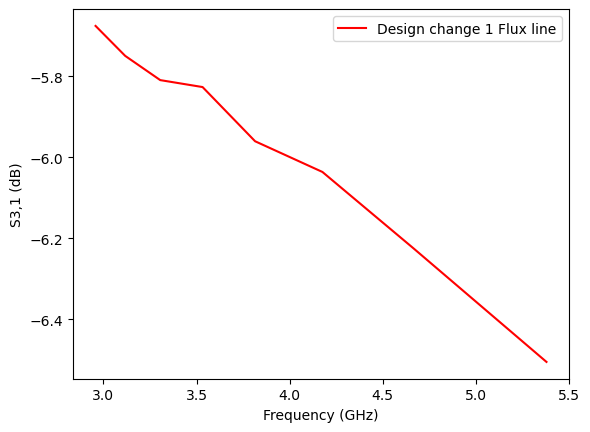

In [9]:
#max S parameter vs frequency plot
plt.plot(res_freq_design1,res_mag_design1, 'r',label = 'Design change 1 Flux line')
#plt.plot(res_freq_design0,res_mag_design0, 'b', label='Design 0 Flux line')
#plt.plot(res_freq_design0_drive,res_mag_design0_drive,'g', label='Design 0 Drive line')
plt.xlabel('Frequency (GHz)')
plt.ylabel('S3,1 (dB)')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

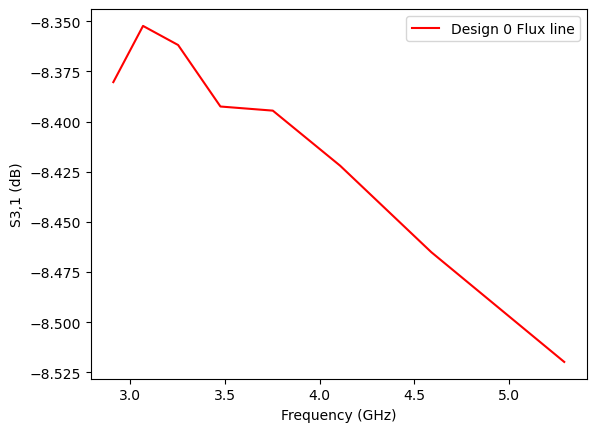

In [10]:
#max S parameter vs frequency plot
plt.plot(res_freq_design0,res_mag_design0, 'r', label='Design 0 Flux line')
plt.xlabel('Frequency (GHz)')
plt.ylabel('S3,1 (dB)')
plt.legend()
plt.show

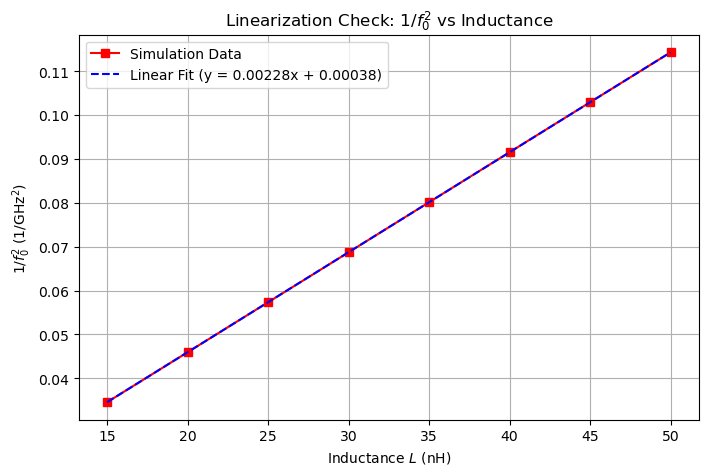

Qubit capacitance is: 0.00005772 nF
Or Qubit capacitance: 57.72 fF


In [11]:
# 4. Physics Check: Plot 1 / f_0^2 vs Inductance to extract capacitance
plt.figure(figsize=(8, 5))
y_vals = 1.0 / (res_freq_design1 ** 2)
plt.plot(inductances, y_vals, 's-', color='red', label='Simulation Data')

# Fit a line (y = mx + c)
slope, intercept = np.polyfit(inductances, y_vals, 1) #slope = m , intercept = c
plt.plot(inductances, slope * inductances + intercept, '--', color='blue', 
         label=f'Linear Fit (y = {slope:.5f}x + {intercept:.5f})')

plt.xlabel('Inductance $L$ (nH)')
plt.ylabel('$1 / f_0^2$ ($1/\mathrm{GHz}^2$)')
plt.title('Linearization Check: $1/f_0^2$ vs Inductance')
plt.legend()
plt.grid(True)
plt.show()

#Inductance calculation:
Qubit_inductance = slope/(4*np.pi**2)
print(f'Qubit capacitance is: {Qubit_inductance:.8f} nF')
print(f'Or Qubit capacitance: {Qubit_inductance*1e6:.2f} fF')

<function matplotlib.pyplot.show(close=None, block=None)>

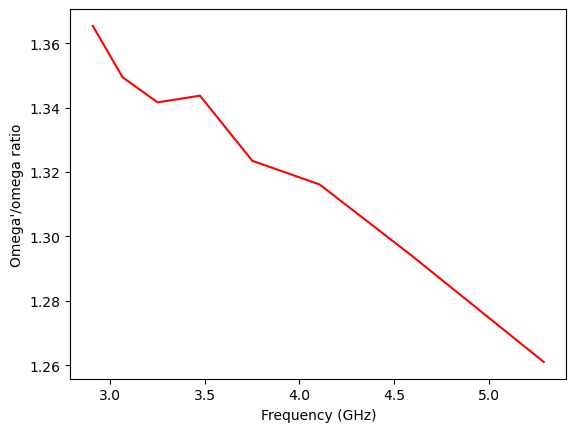

In [12]:
#change lists to arrays for calculations:
res_mag_design0 = np.array(res_mag_design0)
res_mag_design1 = np.array(res_mag_design1)
res_mag_design0_drive = np.array(res_mag_design0_drive)

#Post processing check for omega drive strength:
#Flux drive ratio: First change db to voltage_in/voltage_out:
def Db_to_Voltage(db):
    return 10**(db/20)

res_vol_design0 = np.zeros(len(res_freq_design0))
res_vol_design1 = np.zeros(len(res_freq_design1))
res_vol_drive = np.zeros(len(res_freq_design0_drive))

for i in range((len(res_freq_design0))):
    res_vol_design0[i] = (Db_to_Voltage(res_mag_design0[i]))
for i in range((len(res_freq_design1))):    
    res_vol_design1[i] = (Db_to_Voltage(res_mag_design1[i]))
for i in range((len(res_freq_design0_drive))):
    res_vol_drive[i] = (Db_to_Voltage(res_mag_design0_drive[i]))

Omega_design_10_ratio = res_vol_design1/res_vol_design0

plt.plot(res_freq_design0,Omega_design_10_ratio,'r')
plt.xlabel('Frequency (GHz)')
plt.ylabel("Omega'/omega ratio")
plt.show

In [13]:
def recipt(f, Cd):
    return 1/(Cd*50*2*np.pi*f)

curve_fit(recipt, res_freq_design0_drive, res_mag_design0_drive)

(array([3300.99928973]), array([[1.56911821e+21]]))

[0.00463651]


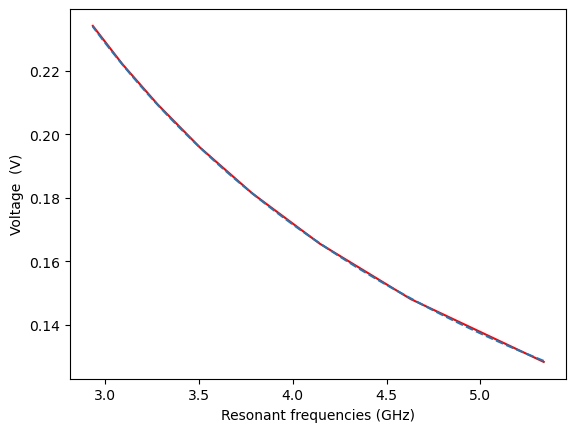

In [14]:
plt.plot(res_freq_design0_drive,res_vol_drive,'r')
x = np.linspace(res_freq_design0_drive[0], res_freq_design0_drive[-1])

def recipt(f, Cd):
    return 1/(Cd*50*2*np.pi*f)

Cd, cd_err = curve_fit(recipt, res_freq_design0_drive, res_vol_drive)

plt.plot(x, recipt(x, Cd), '--')
plt.xlabel('Resonant frequencies (GHz)')
plt.ylabel("Voltage  (V)")
plt.show

print(Cd)

# Design 2 drive drive #

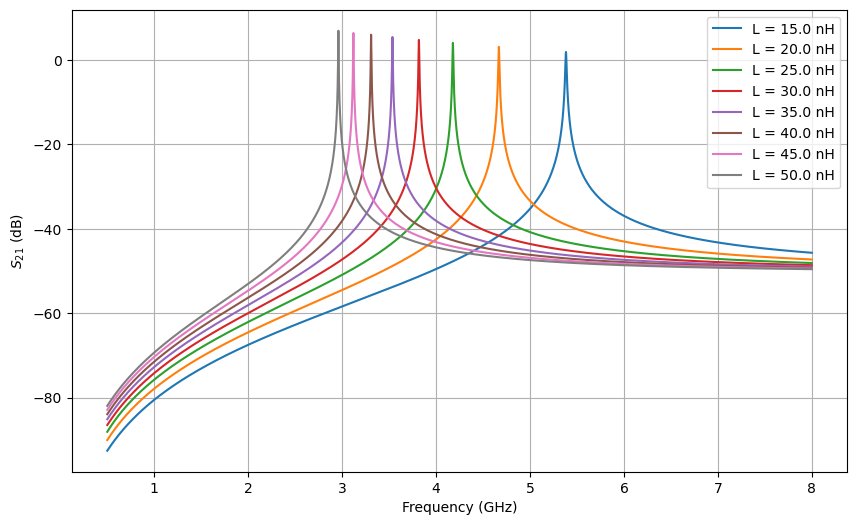

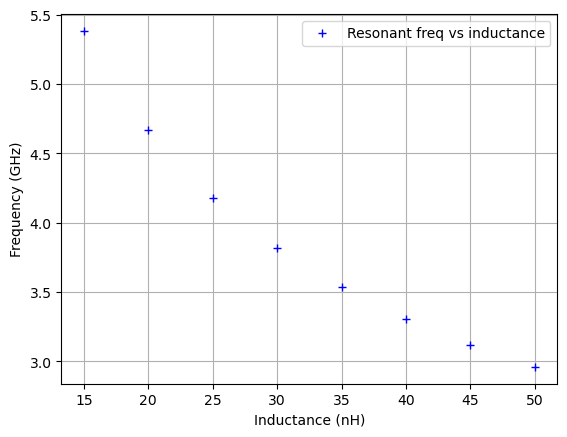

In [15]:
# 1. Initialize variables to parse the stacked file
current_inductance = None
data_by_inductance = {}

# 2. Open and split the file by inductance values
with open('Design2_Corrected_drive_drive.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        # When we find a new sweep header, extract the inductance value
        if line.startswith('#Parameters'):
            match = re.search(r'inductance=([\d\.]+)', line)
            if match:
                current_inductance = float(match.group(1))
                data_by_inductance[current_inductance] = []
        elif line.startswith('#'):
            continue  # Skip other comment rows
        else:
            # Append numerical rows to the active inductance sweep
            if current_inductance is not None:
                parts = line.split()
                if len(parts) == 2:
                    data_by_inductance[current_inductance].append([float(parts[0]), float(parts[1])])

# 3. Process each sweep to find its resonance peak
inductances = []
res_freq_design2_drive = []
res_mag_design2_drive = []

plt.figure(figsize=(10, 6))
for L in sorted(data_by_inductance.keys()):
    # Convert lists to a clean 2D NumPy array
    arr = np.array(data_by_inductance[L])
    freq = arr[:, 0]  # Frequency (GHz)
    mag = arr[:, 1]   # Magnitude (dB)
    
    # Locate the highest peak (maximum voltage transmission)
    peak_idx = np.argmax(mag)
    f_peak = freq[peak_idx]
    mag_peak = mag[peak_idx]
    
    # Save values for the final analysis
    inductances.append(L)
    res_freq_design2_drive.append(f_peak)
    res_mag_design2_drive.append(mag_peak)
    
    # Plot the individual curve to see the resonance shifts
    plt.plot(freq, mag, label=f'L = {L} nH')

plt.xlabel('Frequency (GHz)')
plt.ylabel(r'$S_{21}$ (dB)')
#plt.title('Resonance Shift Across Different Inductances')
plt.legend()
plt.grid(True)
#plt.savefig('design3_peak_S31_drive.pdf')
plt.show()

# Convert tracking lists to NumPy arrays for calculations
inductances = np.array(inductances)
res_freq_design2_drive = np.array(res_freq_design2_drive)

plt.plot(inductances, res_freq_design2_drive, 'b+', label='Resonant freq vs inductance')
plt.xlabel('Inductance (nH)')
plt.ylabel('Frequency (GHz)')
plt.legend()
plt.grid(True)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

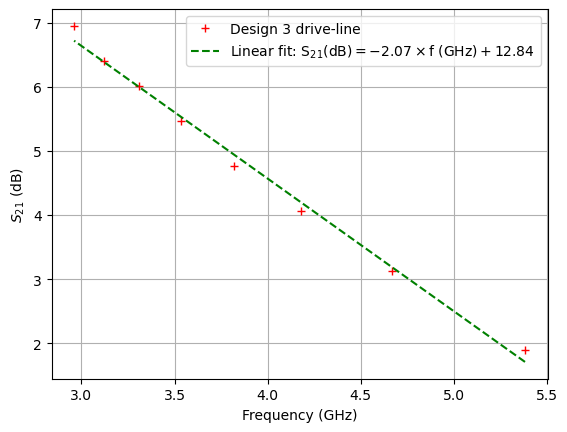

In [19]:
# Fit a line (y = mx + c)
slope, intercept = np.polyfit(res_freq_design2_drive, res_mag_design2_drive, 1) #slope = m , intercept = c

#max S parameter vs frequency plot
plt.plot(res_freq_design2_drive,res_mag_design2_drive, 'r+', label='Design 3 drive-line')
plt.plot(res_freq_design2_drive, slope * res_freq_design2_drive + intercept,'--', color='green', 
         label=rf'Linear fit: $\text{{S}}_{{21}}(\text{{dB}}) = {slope:.2f}\times\text{{f (GHz)}}+{intercept:.2f}$')
plt.xlabel('Frequency (GHz)')
plt.ylabel(r'$S_{21}$ (dB)')
plt.legend()
plt.grid(True)
#plt.savefig('design3_driveline_peak_S31_frequency.pdf')
plt.show

# Design 2 flux drive #

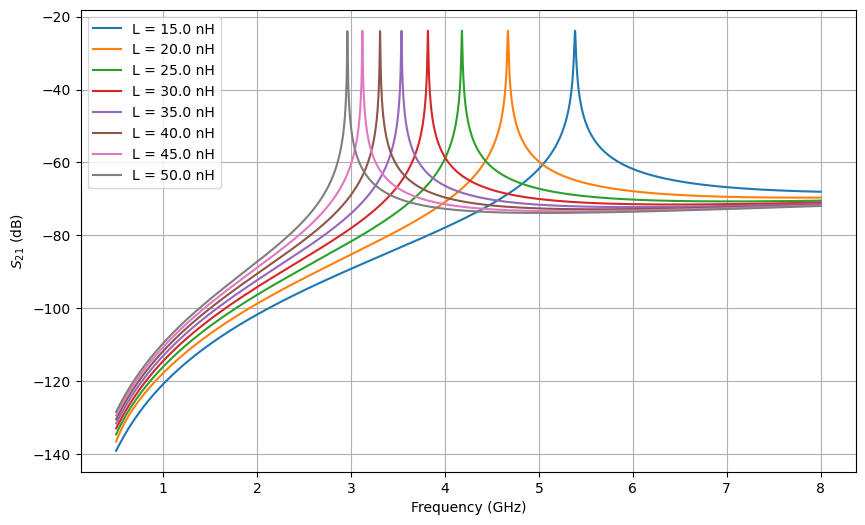

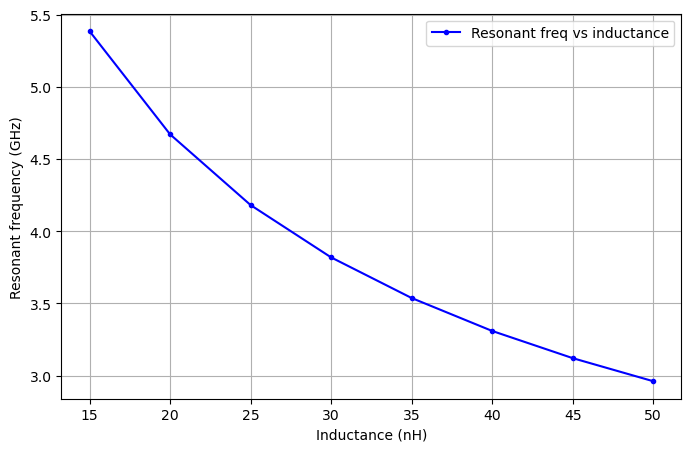

In [17]:
# 1. Initialize variables to parse the stacked file
current_inductance = None
data_by_inductance = {}

# 2. Open and split the file by inductance values
with open('Design2_Corrected_Flux_drive.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        # When we find a new sweep header, extract the inductance value
        if line.startswith('#Parameters'):
            match = re.search(r'inductance=([\d\.]+)', line)
            if match:
                current_inductance = float(match.group(1))
                data_by_inductance[current_inductance] = []
        elif line.startswith('#'):
            continue  # Skip other comment rows
        else:
            # Append numerical rows to the active inductance sweep
            if current_inductance is not None:
                parts = line.split()
                # Changed from 2 to 3 to extract frequency, real, and imaginary columns
                if len(parts) == 3:
                    data_by_inductance[current_inductance].append([
                        float(parts[0]),  # Frequency
                        float(parts[1]),  # Real part [Re]
                        float(parts[2])   # Imaginary part [Im]
                    ])

# 3. Process each sweep to find its resonance peak
inductances = []
res_freq_design2 = []
res_mag_design2 = []

plt.figure(figsize=(10, 6))
for L in sorted(data_by_inductance.keys()):
    # Convert lists to a clean 2D NumPy array
    arr = np.array(data_by_inductance[L])
    freq = arr[:, 0]  # Frequency (GHz)
    real = arr[:, 1]  # Real part [Re]
    imag = arr[:, 2]  # Imaginary part [Im]
    
    # Calculate the linear magnitude from the real and imaginary components
    mag_linear = np.sqrt(real**2 + imag**2)
    
    # Convert linear magnitude to decibels (dB) for S-parameters / voltage transmission
    # np.maximum avoids taking log10 of exactly 0 if any data points are zero
    mag = 20 * np.log10(np.maximum(mag_linear, 1e-15))
    
    # Locate the highest peak (maximum voltage transmission)
    peak_idx = np.argmax(mag)
    f_peak = freq[peak_idx]
    mag_peak = mag[peak_idx]
    
    # Save values for the final analysis
    inductances.append(L)
    res_freq_design2.append(f_peak)
    res_mag_design2.append(mag_peak)
    
    # Plot the individual curve to see the resonance shifts
    plt.plot(freq, mag, label=f'L = {L} nH')

plt.xlabel('Frequency (GHz)')
plt.ylabel(r'$S_{21}$ (dB)')
#plt.title('Resonance Shift Across Different Inductances')
plt.legend()
plt.grid(True)
#plt.savefig('design3_extracted_scattering_data.pdf')
plt.show()

# Convert tracking lists to NumPy arrays for calculations
inductances = np.array(inductances)
res_freq_design2 = np.array(res_freq_design2)

plt.figure(figsize=(8, 5))
plt.plot(inductances, res_freq_design2, 'b.-', label='Resonant freq vs inductance')
plt.xlabel('Inductance (nH)')
plt.ylabel('Resonant frequency (GHz)')
plt.legend()
plt.grid(True)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

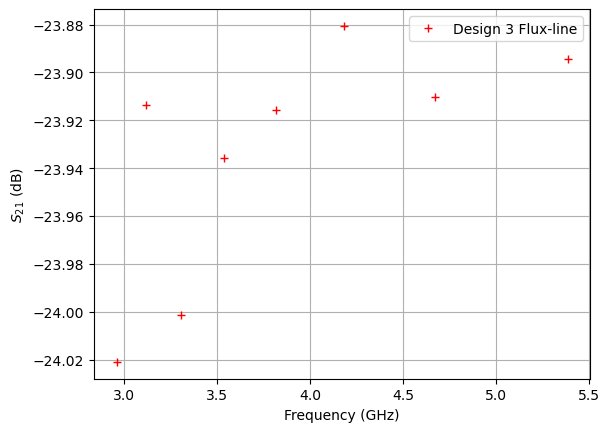

In [18]:
#max S parameter vs frequency plot
plt.plot(res_freq_design2,res_mag_design2, 'r+',label = 'Design 3 Flux-line')
plt.xlabel('Frequency (GHz)')
plt.ylabel(r'$S_{21}$ (dB)')
plt.legend()
plt.grid(True)
#plt.savefig('design3_peak_S31.pdf')
plt.show

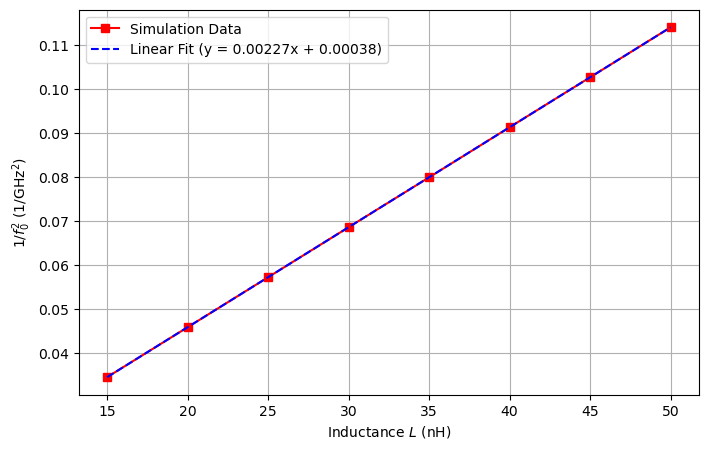

Qubit capacitance is: 0.00005772 nF
Or Qubit capacitance: 57.72 fF


In [19]:
# 4. Physics Check: Plot 1 / f_0^2 vs Inductance to extract capacitance
plt.figure(figsize=(8, 5))
y_vals = 1.0 / (res_freq_design2 ** 2)
plt.plot(inductances, y_vals, 's-', color='red', label='Simulation Data')

# Fit a line (y = mx + c)
slope, intercept = np.polyfit(inductances, y_vals, 1) #slope = m , intercept = c
plt.plot(inductances, slope * inductances + intercept, '--', color='blue', 
         label=f'Linear Fit (y = {slope:.5f}x + {intercept:.5f})')

plt.xlabel('Inductance $L$ (nH)')
plt.ylabel('$1 / f_0^2$ ($1/\mathrm{GHz}^2$)')
#plt.title('Linearization Check: $1/f_0^2$ vs Inductance')
plt.legend()
plt.grid(True)
#plt.savefig('design3_qubit_capacitance.pdf')
plt.show()

#Inductance calculation:
Qubit_capacitance = slope/(4*np.pi**2)
print(f'Qubit capacitance is: {Qubit_inductance:.8f} nF')
print(f'Or Qubit capacitance: {Qubit_inductance*1e6:.2f} fF')

# All in one graph #

[-6.50551544 -6.22494151 -6.03622977 -5.9603874  -5.8264993  -5.80934044
 -5.74944473 -5.67546426]
[np.float64(1.9030127868413), np.float64(3.1205777905576), np.float64(4.0591228447029), np.float64(4.7716010107523), np.float64(5.4606519129215), np.float64(6.0074443965361), np.float64(6.4071893604041), np.float64(6.9490137360931)]


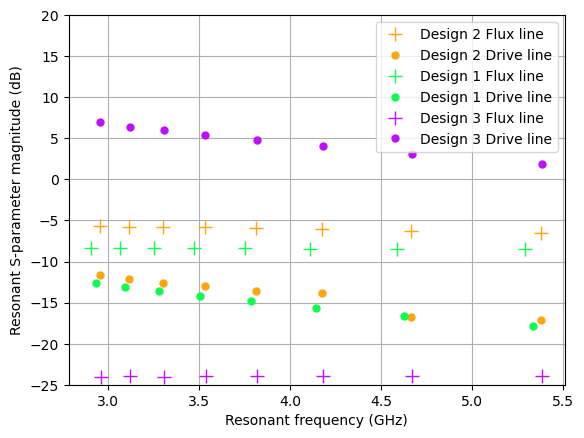

In [29]:
size = 10
#max S parameter vs frequency plot
plt.plot(res_freq_design1,res_mag_design1, color='#FCA50F', marker='+',markersize=size, linestyle='',label = 'Design 2 Flux line')
plt.plot(res_freq_design1_drive,res_mag_design1_drive,color='#FCA50F', marker='.',markersize=size, linestyle='', label='Design 2 Drive line')
plt.plot(res_freq_design0,res_mag_design0, color='#0FFC52', marker='+', linestyle='',markersize=size, label='Design 1 Flux line')
plt.plot(res_freq_design0_drive,res_mag_design0_drive,color='#0FFC52', marker='.',markersize=size, linestyle='', label='Design 1 Drive line')
plt.plot(res_freq_design2,res_mag_design2, color='#BD0FFC', marker='+', linestyle='',markersize=size,label = 'Design 3 Flux line')
plt.plot(res_freq_design2_drive,res_mag_design2_drive, color='#BD0FFC', marker='.',markersize=size, linestyle='',label = 'Design 3 Drive line')
plt.xlabel('Resonant frequency (GHz)')
plt.ylabel('Resonant S-parameter magnitude (dB)')
plt.ylim(-25,20)
plt.legend(fontsize=10)
plt.grid(True)
#plt.savefig('Bep_Resonance_drive_combined.pdf')
plt.show
print(res_mag_design1)
print(res_mag_design2_drive)

# Omega factor analysis #

NameError: name 'design0_voltage_in' is not defined

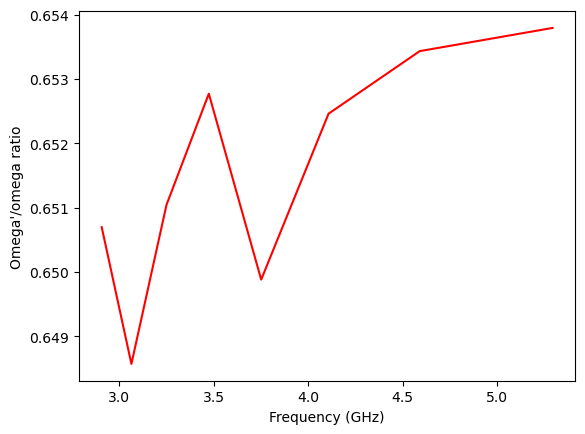

In [20]:
#design 1 against design 0 flux line S_31 parameters ratio:
plt.figure()
plt.plot(res_freq_design0,Omega_design_10_ratio,'r')
plt.xlabel('Frequency (GHz)')
plt.ylabel("Omega'/omega ratio")
plt.show

#design 0 flux line input port voltage:
for i in range((len(design0_voltage_frequency))):
    design0_voltage_in[i] = (Db_to_Voltage(design0_voltage_in_db[i]))

# For each frequency in resonance, find the index of the closest frequency in voltage
indices_freq_design0 = np.abs(design0_voltage_frequency - res_freq_design0[:, None]).argmin(axis=1)
# Extract the aligned data from the dense array
design0_voltage_in = design0_voltage_in[indices_freq_design0]
design0_voltage_frequency = design0_voltage_frequency[indices_freq_design0]

#Voltage in at resonance points:
plt.figure()
plt.plot(design0_voltage_frequency,design0_voltage_in, 'r+')
plt.xlabel('Frequency (GHz)')
plt.ylabel("Voltage in (V)")
plt.grid(True)
plt.show